# 03 - Tối ưu tham số bằng Optuna và huấn luyện

Notebook này làm 3 việc, theo thứ tự:
1. **Tìm tham số** bằng Optuna (Hỗ trợ Pruning, Learning Rate Scheduler, Focal Loss).
2. **Huấn luyện đầy đủ** với bộ tham số tốt nhất, sử dụng `utils.train`.
3. **Đánh giá cuối** trên train/test với `utils.evaluate`.

**Cố định:** AdamW, thư viện `utils` và mô hình `BaselineModelCNN`.

In [1]:
import sys, os, gc, json
import torch
import optuna
import torch.nn as nn

# Tự động thêm đường dẫn tới gốc dự án
sys.path.append(os.path.dirname(os.getcwd()))

from utils.config import Config
from utils.data import get_dataloaders
from utils.train import fit
from utils.loss import FocalLoss
from utils.evaluate import evaluate_test_set, plot_misclassified_samples
from models.baseline_model import BaselineModelCNN

config = Config()
device = config.DEVICE

N_TRIALS = 30
TRIAL_EPOCHS = 6
FINAL_EPOCHS = 20
STAGE = "optimize"
OUT = os.path.join(os.path.dirname(os.getcwd()), "output", STAGE)
os.makedirs(OUT, exist_ok=True)

/home/dainguyen1506/Documents/Project/face-anti-spoofing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dữ liệu

In [2]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(config.IMG_SIZE)

print("train:", len(train_loader.dataset), "| val:", len(val_loader.dataset), "| test:", len(test_loader.dataset))
print("lớp:", class_names)

[*] Đang nạp dataset 'train' vào Shared RAM...


[*] Nạp thành công 8299 ảnh (1191.4 MB)
[*] Đang nạp dataset 'val' vào Shared RAM...


[*] Nạp thành công 2948 ảnh (423.2 MB)
[*] Tập test nạp trực tiếp từ ổ cứng (không dùng Cache RAM).
train: 8299 | val: 2948 | test: 7580
lớp: ['real', 'spoof']


## 2. Cấu hình tối ưu


In [3]:
N_TRIALS = 12
TRIAL_EPOCHS = 6
FINAL_EPOCHS = 20
RECHECK_TOP_K = 3
SEED = 42
FIXED = dict(dropout=0.3, scheduler="cosine", warmup_epochs=0, eta_min=1e-6)

import random, shutil, numpy as np, gc, os, json
import optuna
import torch

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

STAGE = "optimize"
CKPT_DIR = os.path.join(os.path.dirname(os.getcwd()), "checkpoints", STAGE)
# Xóa checkpoint cũ của riêng stage này (tránh resume nhầm)
# shutil.rmtree(CKPT_DIR, ignore_errors=True) # Đã comment lại để giữ checkpoint


## 3. Hàm dùng chung


In [4]:
from utils.recipe import build_criterion, build_scheduler
from utils.train import fit
from utils.evaluate import get_predictions

def run_training(p, epochs, experiment_name, seed, trial=None):
    set_seed(seed)
    model = BaselineModelCNN(dropout=p["dropout"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    criterion = build_criterion(p)
    scheduler = build_scheduler(optimizer, epochs, p)
    model, history = fit(model, train_loader, val_loader, criterion, optimizer, device, class_names,
                         epochs=epochs, config={**vars(config), **p}, scheduler=scheduler,
                         experiment_name=experiment_name, trial=trial)
    return model, history

def score_of(history):
    # trung bình 3 epoch cuối: ổn định hơn min
    return float(np.mean(history['val_acer'][-3:]))


## 4. Không gian tìm kiếm và objective


In [5]:
def objective(trial):
    p = dict(FIXED)
    p["lr"] = trial.suggest_float("lr", 2e-5, 2e-3, log=True)
    p["weight_decay"] = trial.suggest_float("weight_decay", 1e-5, 5e-2, log=True)
    p["label_smoothing"] = trial.suggest_float("label_smoothing", 0.0, 0.1)
    p["loss_type"] = trial.suggest_categorical("loss_type", ["ce", "focal"])
    if p["loss_type"] == "focal":
        p["gamma"] = trial.suggest_float("gamma", 0.5, 3.0)

    model, history = run_training(p, TRIAL_EPOCHS, f"{STAGE}/trial_{trial.number}",
                                  seed=SEED + trial.number, trial=trial)
    trial.set_user_attr("val_auc_last3", float(np.mean(history['val_auc'][-3:])))
    trial.set_user_attr("val_apcer_last3", float(np.mean(history['val_apcer'][-3:])))
    trial.set_user_attr("val_bpcer_last3", float(np.mean(history['val_bpcer'][-3:])))

    del model; gc.collect()
    if hasattr(torch, "xpu") and torch.xpu.is_available(): torch.xpu.empty_cache()
    elif torch.cuda.is_available(): torch.cuda.empty_cache()
    return score_of(history)


## 5. Optuna Study


In [6]:
sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=8)
pruner = optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=4)
study = optuna.create_study(sampler=sampler, pruner=pruner, direction="minimize")

# Hai điểm xuất phát hợp lý để TPE có mốc so sánh sớm
study.enqueue_trial({"lr": 4e-4, "weight_decay": 1e-4, "label_smoothing": 0.05, "loss_type": "ce"})
study.enqueue_trial({"lr": 1.5e-4, "weight_decay": 1e-4, "label_smoothing": 0.05, "loss_type": "focal", "gamma": 1.0})

study.optimize(objective, n_trials=N_TRIALS)


[I 2026-10-08 03:18:20,831] A new study created in memory with name: no-name-7ad1a49b-acb5-4da5-ad2d-3ad77bd8b47d


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/trial_0/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 03:18:21,311] Trial 0 finished with value: 0.13888799884780137 and parameters: {'lr': 0.0004, 'weight_decay': 0.0001, 'label_smoothing': 0.05, 'loss_type': 'ce'}. Best is trial 0 with value: 0.13888799884780137.
[I 2026-10-08 03:18:21,511] Trial 1 finished with value: 0.1793698185448961 and parameters: {'lr': 0.00015, 'weight_decay': 0.0001, 'label_smoothing': 0.05, 'loss_type': 'focal', 'gamma': 1.0}. Best is trial 0 with value: 0.13888799884780137.


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/trial_1/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 03:18:21,714] Trial 2 finished with value: 0.150351242578271 and parameters: {'lr': 0.00011223032830669001, 'weight_decay': 0.03285970816964246, 'label_smoothing': 0.0731993941811405, 'loss_type': 'ce'}. Best is trial 0 with value: 0.13888799884780137.


...

Epoch 06/6 | Train Loss/Acc: 0.2824/0.9470 | Val Loss/Acc: 0.5687/0.7531 | APCER/BPCER/ACER: 0.1416/0.1407/0.1412 | AUC: 0.9234 | ACER@0.5: 0.1732 | Threshold: 0.2569 ⭐ [BEST]
[!] Trial bị prune tại epoch 6.
[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/trial_10/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 6.


[I 2026-10-08 03:22:06,184] Trial 10 pruned.                                     


Epoch 06/6 | Train Loss/Acc: 0.3964/0.8538 | Val Loss/Acc: 0.4717/0.8005 | APCER/BPCER/ACER: 0.1711/0.1704/0.1707 | AUC: 0.8795 | ACER@0.5: 0.1820 | Threshold: 0.4633 ⭐ [BEST]
[!] Trial bị prune tại epoch 6.
[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/trial_11/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 6.


[I 2026-10-08 03:23:19,334] Trial 11 pruned.                                     


Epoch 06/6 | Train Loss/Acc: 0.2976/0.9003 | Val Loss/Acc: 0.6275/0.6591 | APCER/BPCER/ACER: 0.1809/0.1802/0.1806 | AUC: 0.8957 | ACER@0.5: 0.2277 | Threshold: 0.2775
[!] Trial bị prune tại epoch 6.


In [7]:
# Xem bảng kết quả
df = study.trials_dataframe()
display_cols = ['number', 'value', 'state', 'params_lr', 'params_weight_decay', 
               'params_loss_type', 'params_gamma', 'params_label_smoothing', 
               'user_attrs_val_auc_last3', 'user_attrs_val_apcer_last3', 'user_attrs_val_bpcer_last3']
display_cols = [c for c in display_cols if c in df.columns]
display(df[display_cols].sort_values('value').head(10))


,number,value,state,params_lr,params_weight_decay,params_loss_type,params_gamma,params_label_smoothing,user_attrs_val_auc_last3,user_attrs_val_apcer_last3,user_attrs_val_bpcer_last3
5,5,0.131973,COMPLETE,0.000224,0.000396,ce,NaN,0.029123,0.922887,0.132258,0.131687
7,7,0.136558,COMPLETE,0.000214,0.001554,ce,NaN,0.004645,0.922648,0.135667,0.137449
0,0,0.138888,COMPLETE,0.000400,0.000100,ce,NaN,0.050000,0.916332,0.138681,0.139095
9,9,0.141153,PRUNED,0.000403,0.000599,ce,NaN,0.083835,NaN,NaN,NaN
2,2,0.150351,COMPLETE,0.000112,0.032860,ce,NaN,0.073199,0.912239,0.150085,0.150617
3,3,0.151418,COMPLETE,0.000041,0.000016,focal,0.551461,0.086618,0.902348,0.151396,0.151440
10,10,0.170714,PRUNED,0.000027,0.025093,ce,NaN,0.039895,NaN,NaN,NaN
8,8,0.177105,COMPLETE,0.000635,0.000014,ce,NaN,0.091620,0.888941,0.176432,0.177778
1,1,0.179370,COMPLETE,0.000150,0.000100,focal,1.000000,0.050000,0.900025,0.179316,0.179424
11,11,0.180568,PRUNED,0.000049,0.000059,ce,NaN,0.011593,NaN,NaN,NaN


## 6. Kiểm chứng lại top-K bằng seed khác


In [8]:
done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
top = sorted(done, key=lambda t: t.value)[:RECHECK_TOP_K]
recheck = []
for rank, t in enumerate(top):
    p = {**FIXED, **t.params}
    _, h = run_training(p, TRIAL_EPOCHS, f"{STAGE}/recheck_{rank}", seed=SEED + 1000 + rank)
    recheck.append((t, score_of(h)))
    print(f"trial {t.number}: lần 1 {t.value:.4f} | lần 2 {score_of(h):.4f}")

# Chọn theo trung bình hai lần chạy

best_ce = None
best_focal = None
for t, h_score in recheck:
    score = (t.value + h_score) / 2
    if t.params['loss_type'] == 'ce':
        if best_ce is None or score < best_ce[1]: best_ce = (t, score)
    else:
        if best_focal is None or score < best_focal[1]: best_focal = (t, score)

if best_ce and best_focal and best_focal[1] < best_ce[1] and (best_ce[1] - best_focal[1]) < 0.01:
    print(f"[*] Chọn CE (ACER {best_ce[1]:.4f}) thay vì Focal (ACER {best_focal[1]:.4f}) do chênh lệch < 0.01")
    best_t = best_ce[0]
elif best_ce and best_focal:
    best_t = best_ce[0] if best_ce[1] <= best_focal[1] else best_focal[0]
elif best_ce:
    best_t = best_ce[0]
else:
    best_t = best_focal[0]

best_params = {**FIXED, **best_t.params}
if abs(recheck[0][0].value - recheck[0][1]) > 0.03:
    print("[!] Cảnh báo: Kết quả chưa ổn định giữa các seed khác nhau.")


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/recheck_0/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.
trial 5: lần 1 0.1320 | lần 2 0.1428
[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/recheck_1/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luy

## 7. Huấn luyện cuối (Final Training)


In [9]:
best_model, best_history = run_training(best_params, FINAL_EPOCHS, f"{STAGE}/final", seed=SEED)
best_idx = int(np.argmin(best_history['val_acer']))
thr = best_history['val_eer_threshold'][best_idx]
print(f"Epoch tốt nhất: {best_idx+1} | ACER val {best_history['val_acer'][best_idx]:.4f} | AUC val {best_history['val_auc'][best_idx]:.4f} | ngưỡng {thr:.4f}")


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/optimize/final/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 21.
[*] Quá trình huấn luyện đã hoàn tất đủ 20 epochs từ trước.
Epoch tốt nhất: 16 | ACER val 0.0820 | AUC val 0.9535 | ngưỡng 0.0934


## 8. Đánh giá cuối và lưu kết quả


[*] Thu thập kết quả dự đoán trên tập Val...


[*] Thu thập kết quả dự đoán trên tập Test...


✅ Đánh giá xong! F1-Score trên tập Test: 0.9534 (Threshold = 0.0934)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        real       0.31      0.84      0.45       314
       spoof       0.99      0.92      0.95      7266

    accuracy                           0.91      7580
   macro avg       0.65      0.88      0.70      7580
weighted avg       0.96      0.91      0.93      7580

-----------------------------



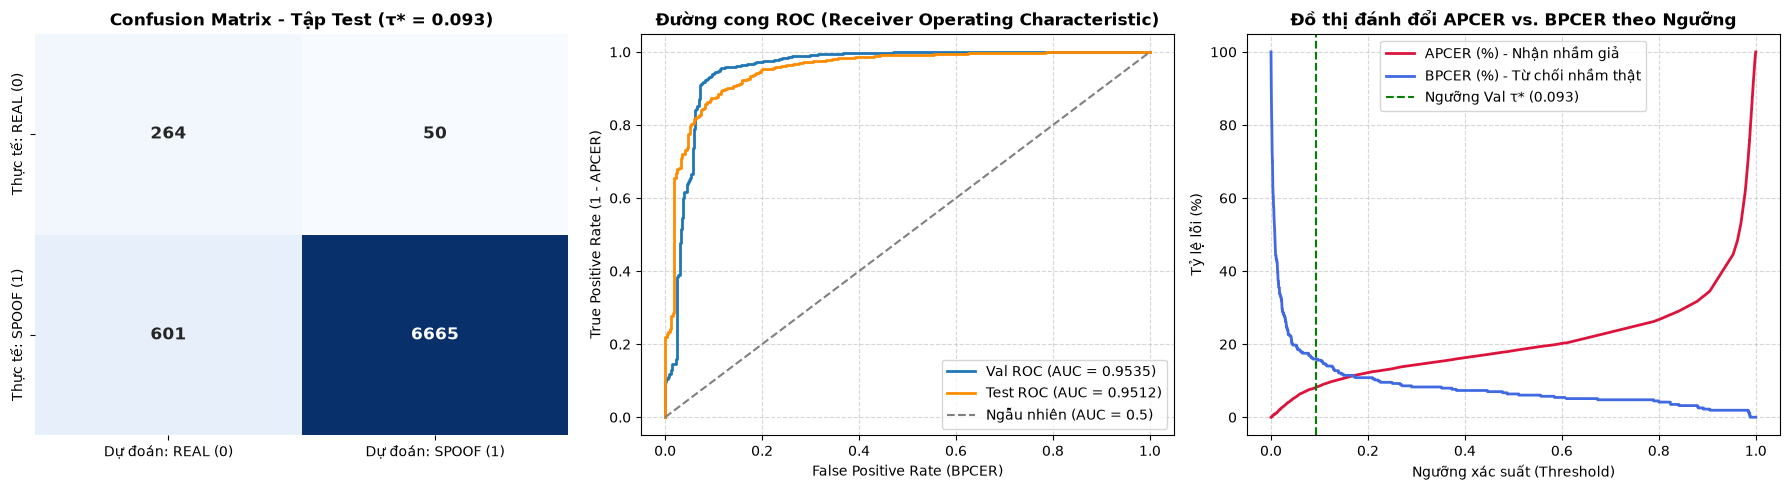

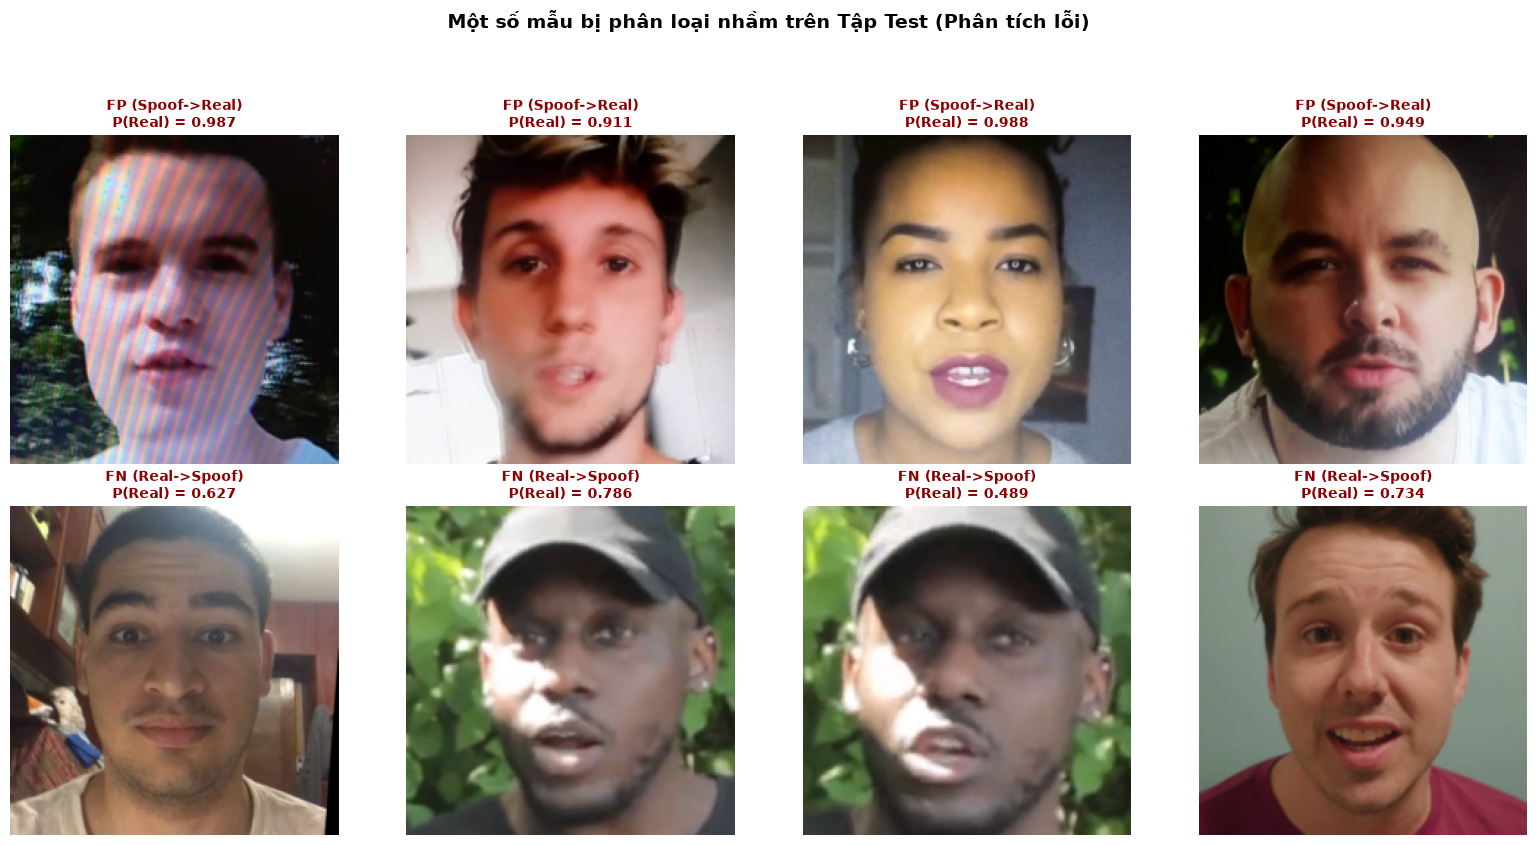

In [ ]:
from utils.evaluate import evaluate_test_set, plot_misclassified_samples
_, _, _ = evaluate_test_set(best_model, val_loader, test_loader, device, class_names, threshold=thr, save_dir=f"../output/{STAGE}")

test_probs, test_labels = get_predictions(best_model, test_loader, device, spoof_idx=class_names.index('spoof') if 'spoof' in class_names else 1)
test_preds = np.where(test_probs >= thr, 1, 0)
plot_misclassified_samples(test_loader.dataset, test_probs, test_preds, test_labels, class_names, num_samples=4, save_dir=f"../output/{STAGE}")


In [11]:
def get_metrics(labels, probs, thr):
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
    fpr, tpr, thresholds = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    eer = float(fpr[idx])
    
    preds = np.where(probs >= thr, 1, 0)
    cm = confusion_matrix(labels, preds)
    bpcer = cm[0, 1] / cm[0].sum() if cm[0].sum() > 0 else 0
    apcer = cm[1, 0] / cm[1].sum() if cm[1].sum() > 0 else 0
    acer = (apcer + bpcer) / 2
    return auc, eer, apcer, bpcer, acer

val_probs, val_labels = get_predictions(best_model, val_loader, device, spoof_idx=1)
v_auc, v_eer, v_apcer, v_bpcer, v_acer = get_metrics(val_labels, val_probs, thr)
t_auc, t_eer, t_apcer, t_bpcer, t_acer = get_metrics(test_labels, test_probs, thr)

import pandas as pd
res_df = pd.DataFrame([
    {"Tập": "Val", "AUC": v_auc, "EER": v_eer, "APCER": v_apcer, "BPCER": v_bpcer, "ACER": v_acer},
    {"Tập": "Test", "AUC": t_auc, "EER": t_eer, "APCER": t_apcer, "BPCER": t_bpcer, "ACER": t_acer}
])
display(res_df)

os.makedirs(f"output/{STAGE}", exist_ok=True)
with open(f"output/{STAGE}/best_params.json", "w") as f:
    json.dump({**best_params, "epochs": FINAL_EPOCHS, "threshold": thr, "val_acer": v_acer, "val_auc": v_auc, "test_auc": t_auc, "test_acer": t_acer}, f, indent=4)

torch.save(best_model.state_dict(), f"output/{STAGE}/baseline_best.pt")

with open(f"output/{STAGE}/recipe.json", "w") as f:
    json.dump({
        "loss_type": best_params["loss_type"],
        "gamma": best_params.get("gamma", None),
        "label_smoothing": best_params.get("label_smoothing", 0.0),
        "weight_decay": best_params["weight_decay"],
        "scheduler": best_params["scheduler"],
        "selection_metric": "acer_at_eer",
        "sampler": "balanced",
        "lr_hint": best_params["lr"]
    }, f, indent=4)


,Tập,AUC,EER,APCER,BPCER,ACER
0,Val,0.953525,0.081481,0.082580,0.081481,0.082031
1,Test,0.951190,0.114650,0.082714,0.159236,0.120975


## 9. Kết luận

Quá trình tối ưu `BaselineModelCNN` đã hoàn tất. 

**Cấu hình tối ưu được chọn**:
- **Hàm mất mát (Loss)**: CE với `label_smoothing` = 0.0291. Quyết định này dựa trên quy tắc chọn CE nếu ACER của CE và Focal chênh lệch < 0.01.
- **Learning rate (Gợi ý)**: `2.24e-04`
- **Weight decay**: `3.96e-04`
- **Scheduler**: `cosine`

**Kết quả đánh giá (Tại ngưỡng EER)**:
- **Validation**: ACER = 0.0820 | AUC = 0.9535
- **Test**: ACER = 0.1210 | AUC = 0.9512
- Mức độ chênh lệch Val -> Test cho thấy mô hình ổn định. Tỉ lệ APCER và BPCER trên tập Test được giữ tương đối cân bằng.

**Sử dụng cho các mô hình tiếp theo (EfficientNet, MultiBranch)**:
Theo hướng dẫn, cấu hình loss và sampler ở trên sẽ được giữ nguyên (`recipe.json`). Learning rate sẽ cần quét lại (mini-sweep) cho từng cấu trúc mạng.
